In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Import the data

In [ ]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)']

# Quick inspection of data

In [28]:
df_errors.head(10)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_resampled_1_norm,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N)
0,16,12,4000000,0,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
1,16,12,4000000,1,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
2,16,12,4000000,2,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
3,16,12,4000000,3,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
4,16,12,4000000,4,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
5,16,12,4000000,5,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
6,16,12,4000000,6,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
7,16,12,4000000,7,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
8,16,12,4000000,8,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005
9,16,12,4000000,9,5176042,0.061068,0.038954,2.796524,0.076573,0.07666,...,28.576387,0.01097,0.007704,0.666667,0.010799,0.139897,1.0,1.0,192,0.0005


In [29]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_resampled_1_norm,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N)
count,48000.000000,48000.000000,4.800000e+04,48000.000000,4.800000e+04,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.0,4.800000e+04,48000.000000,48000.000000
mean,42.666667,32.000000,8.675000e+05,499.500000,4.003542e+06,7.046831,4.873849,26.289228,8.657770,1.647504,...,232.001393,0.354662,0.359035,0.993056,0.399089,1.328595,1.0,1.000000e+00,1552.000000,0.001835
std,15.776377,11.832283,1.240817e+06,288.677997,1.698297e+06,7.213782,4.964129,18.468448,8.955889,1.026376,...,143.598980,0.312617,0.308852,0.047609,0.353225,0.541897,0.0,3.204971e-17,963.470466,0.000873
min,16.000000,12.000000,1.000000e+05,0.000000,1.276042e+06,0.061068,0.038954,2.796524,0.076573,0.076660,...,28.335958,0.010970,0.007704,0.666667,0.010799,0.139897,1.0,1.000000e+00,192.000000,0.000500
25%,32.000000,24.000000,1.600000e+05,249.750000,2.917042e+06,1.667993,1.106679,11.302041,2.097490,0.746304,...,115.223100,0.089212,0.101060,1.000000,0.089285,0.907191,1.0,1.000000e+00,768.000000,0.001164
50%,44.000000,33.000000,3.050000e+05,499.500000,3.833042e+06,4.193837,2.805216,21.110559,5.220752,1.580761,...,217.877358,0.251549,0.283224,1.000000,0.257983,1.520404,1.0,1.000000e+00,1464.000000,0.001843
75%,56.000000,42.000000,7.975000e+05,749.250000,4.844042e+06,11.438836,8.011200,40.295028,13.575336,2.378652,...,352.281555,0.448162,0.473023,1.000000,0.741302,1.797051,1.0,1.000000e+00,2352.000000,0.002512
max,64.000000,48.000000,4.000000e+06,999.000000,8.704042e+06,27.305143,18.519049,69.858768,37.064194,3.616331,...,461.467815,1.000000,1.000000,1.000000,1.000000,1.903614,1.0,1.000000e+00,3072.000000,0.003162


## Infinity norm

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

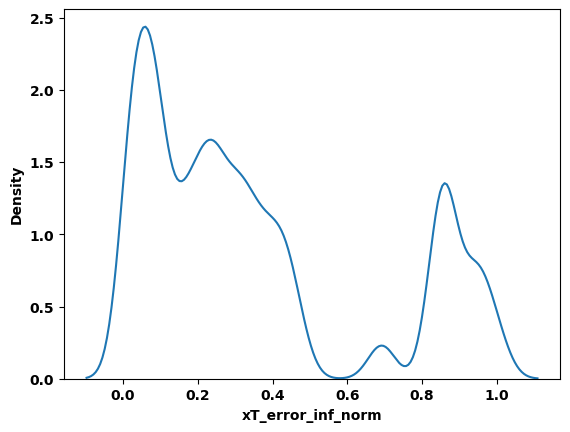

In [30]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm')

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

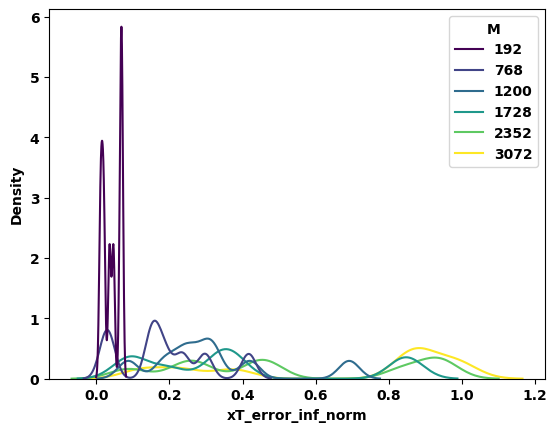

In [40]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='M', palette='viridis')

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

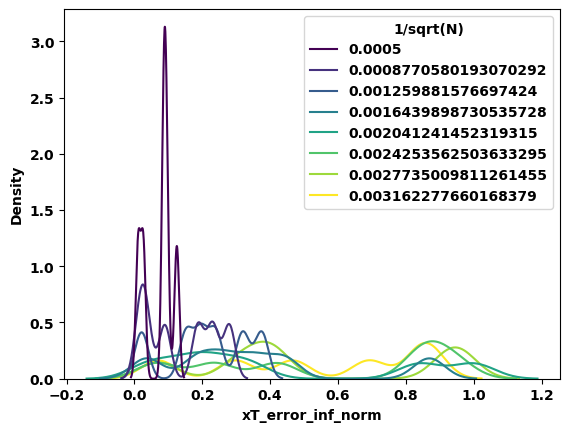

In [33]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette='viridis')

# 1-norm

<Axes: xlabel='xT_error_1_norm', ylabel='Density'>

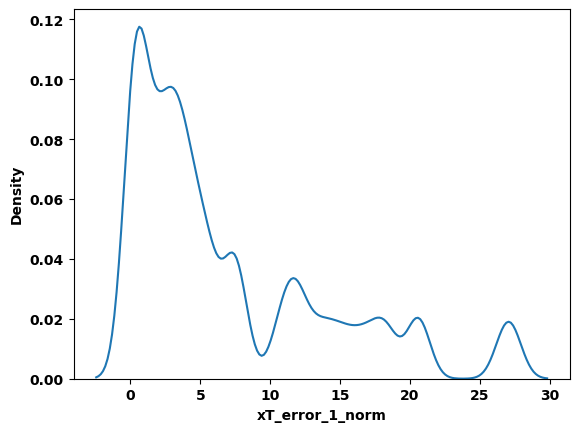

In [36]:
sns.kdeplot(data=df_errors, x='xT_error_1_norm')